In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("malaychand/coco-25-classification-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the 'coco-25-classification-dataset' dataset.
Path to dataset files: /kaggle/input/coco-25-classification-dataset
Contents of base_path (/kaggle/input):
['coco-25-classification-dataset']
Contents of path (/kaggle/input/coco-25-classification-dataset):
['classification']


In [ ]:
print(f"Contents of the 'train' directory: {os.listdir(os.path.join(path, 'classification', 'train'))}")
print(f"Contents of the 'test' directory: {os.listdir(os.path.join(path, 'classification', 'test'))}")

Contents of the 'train' directory: ['motorcycle', 'airplane', 'horse', 'bus', 'truck', 'dog', 'stop sign', 'cup', 'bird', 'car', 'elephant', 'potted plant', 'traffic light', 'cow', 'bicycle', 'chair', 'pizza', 'bench', 'bowl', 'cat', 'bottle', 'cake', 'couch', 'train', 'person']
Contents of the 'test' directory: ['motorcycle', 'airplane', 'horse', 'bus', 'truck', 'dog', 'stop sign', 'cup', 'bird', 'car', 'elephant', 'potted plant', 'traffic light', 'cow', 'bicycle', 'chair', 'pizza', 'bench', 'bowl', 'cat', 'bottle', 'cake', 'couch', 'train', 'person']



--- Sample Images from Training Dataset (/kaggle/input/coco-25-classification-dataset/classification/train) ---
Found 5250 images in /kaggle/input/coco-25-classification-dataset/classification/train. Displaying 6 samples:


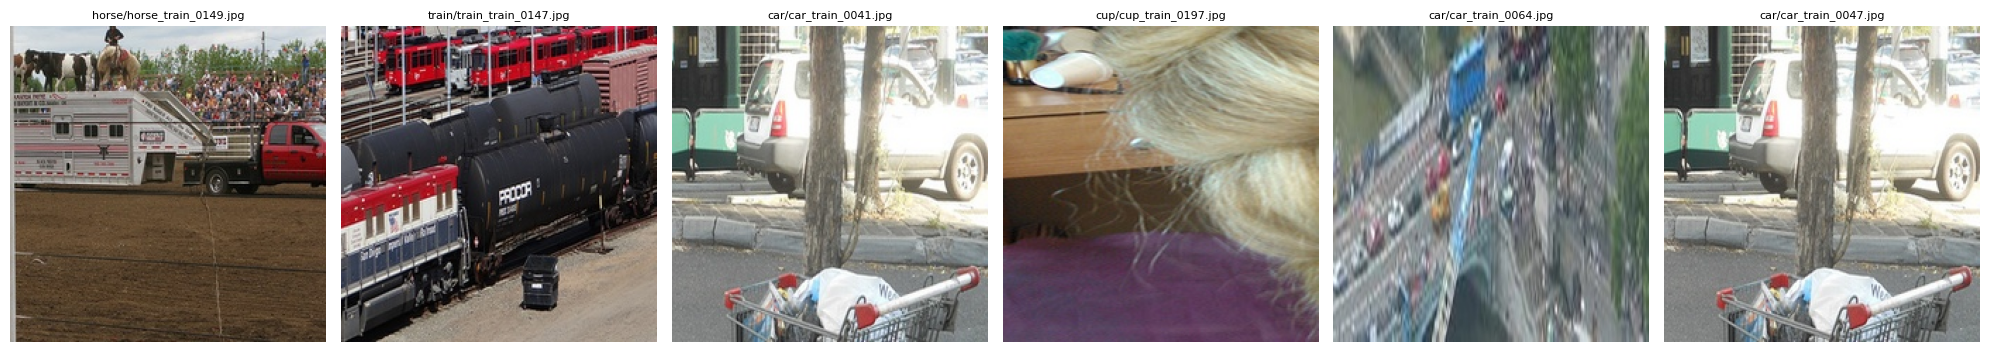


--- Sample Images from Test Dataset (/kaggle/input/coco-25-classification-dataset/classification/test) ---
Found 750 images in /kaggle/input/coco-25-classification-dataset/classification/test. Displaying 6 samples:


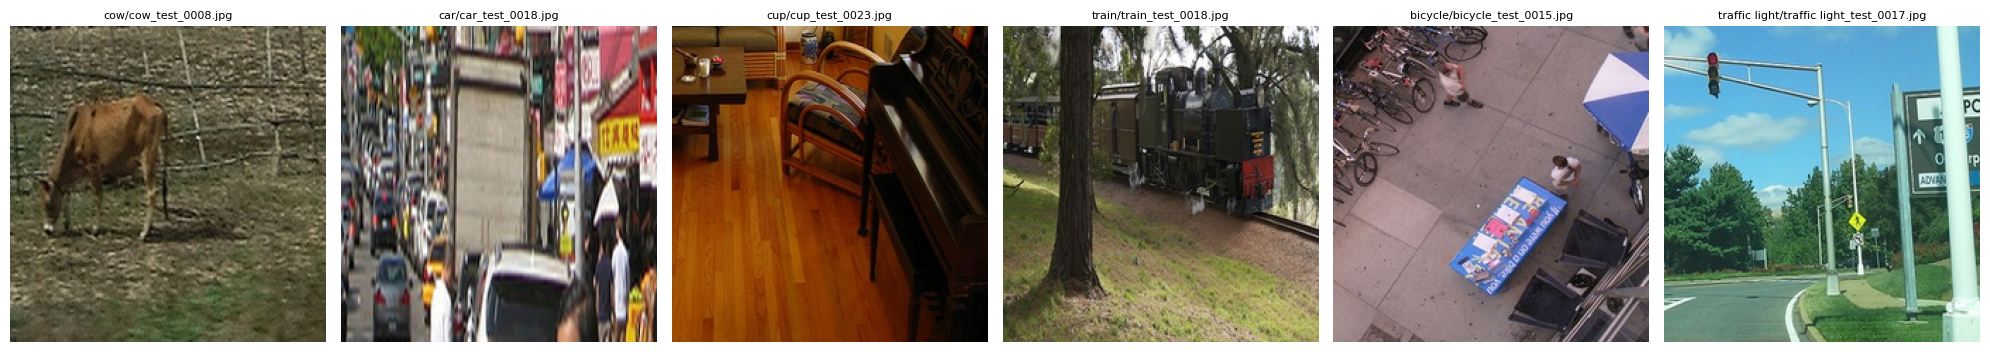

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images in {dataset_path}. Displaying {min(num_samples, len(all_image_paths))} samples:")

    # Select random samples to display
    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]
    elif len(samples_to_display) == 0:
        plt.close(fig)
        return

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(os.path.basename(os.path.dirname(img_path)) + '/' + os.path.basename(img_path), fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Updated paths to include 'classification' subdirectory
train_path = os.path.join(path, 'classification', 'train')
print(f"\n--- Sample Images from Training Dataset ({train_path}) ---")
display_sample_images(train_path)

test_path = os.path.join(path, 'classification', 'test')
print(f"\n--- Sample Images from Test Dataset ({test_path}) ---")
display_sample_images(test_path)

In [ ]:
import tensorflow as tf

# Check if GPU is available
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"GPU is available: {gpu_devices}")
    # Optionally limit memory growth
    for gpu in gpu_devices:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("GPU is not available. Training will be slow on CPU.")

GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNet
from tensorflow.keras import layers, models

# Configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 25

# Data Augmentation and Loading
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# Build MobileNet Model
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False # Freeze base model initially

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Found 4200 images belonging to 25 classes.
Found 1050 images belonging to 25 classes.
17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenet_1.00_224 (Functional) │ (None, 7, 7, 1024)     │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         6,425 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,497,689 (13.34 MB)

 Trainable params: 268,825 (1.03 MB)

 Non-trainable params: 3,228,864 (12.32 MB)

In [ ]:
# Training the model
EPOCHS = 10
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator
)

Epoch 1/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 120s 788ms/step - accuracy: 0.2652 - loss: 2.5942 - val_accuracy: 0.5000 - val_loss: 1.7287
Epoch 2/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 66s 500ms/step - accuracy: 0.4521 - loss: 1.8298 - val_accuracy: 0.5848 - val_loss: 1.3962
Epoch 3/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 67s 507ms/step - accuracy: 0.5264 - loss: 1.5491 - val_accuracy: 0.6257 - val_loss: 1.2965
Epoch 4/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 73s 555ms/step - accuracy: 0.5750 - loss: 1.4093 - val_accuracy: 0.6476 - val_loss: 1.2163
Epoch 5/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 66s 501ms/step - accuracy: 0.6000 - loss: 1.2961 - val_accuracy: 0.6629 - val_loss: 1.1761
Epoch 6/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 67s 513ms/step - accuracy: 0.6307 - loss: 1.2190 - val_accuracy: 0.6676 - val_loss: 1.0817
Epoch 7/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 67s 510ms/step - accuracy: 0.6510 - loss: 1.1579 - val_accuracy: 0.6905 - val_loss: 1.0675
Epoch 8/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 69s 520ms/step - accuracy: 0.6681 - loss: 

In [ ]:
# Summary of training results
loss, accuracy = model.evaluate(validation_generator)
print(f"Final Validation Loss: {loss:.4f}")
print(f"Final Validation Accuracy: {accuracy:.4f}")

33/33 ━━━━━━━━━━━━━━━━━━━━ 14s 410ms/step - accuracy: 0.7162 - loss: 0.9845
Final Validation Loss: 0.9845
Final Validation Accuracy: 0.7162


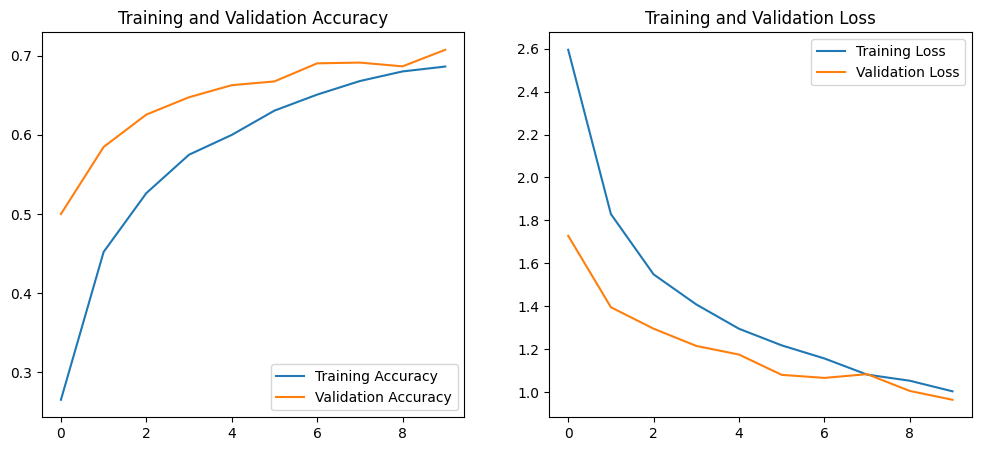

In [ ]:
# Visualize training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()